# Etude 1: Régression linéaire simple

Référénce: https://oraprdnt.uqtr.uquebec.ca/Gscdepot/paf1010/19/M13.pdf


Importer les librairies : numpy, pandas, matplolib,...

In [ ]:
# Linear algebra
import numpy as np 

# Data processing
import pandas as pd 

# Data visualization
import seaborn as sns
%matplotlib inline
from matplotlib import pyplot as plt
from matplotlib import style

## Partie 1 - Une première base de données  


### Importation de données et analyse exploratoire

1) Lire le fichier dataset1.csv sous forme tableau de données utilisant pandas et afficher les 5 premières lignes du tableau

Indice: read_csv, head

In [15]:
df = pd.read_csv('dataset1.csv', delimiter=';')
df.head()

,x,y
0,0,46.357215
1,1,46.080189
2,2,45.077372
3,3,48.480649
4,4,43.666733


2) Afficher un résumé concis du DataFrame pour comprendre les données (les colonnes, nombre d'éléments non nuls, types de données) 

Indice: info

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       26 non-null     int64  
 1   y       26 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 548.0 bytes


3) Produire des statistiques descriptives du dataset (max, min, mean, etc.) 

Indice: describe

In [17]:
df.describe()

,x,y
count,26.000000,26.000000
mean,12.500000,27.604172
std,7.648529,12.549125
min,0.000000,6.242566
25%,6.250000,17.853984
50%,12.500000,27.263529
75%,18.750000,35.945827
max,25.000000,48.480649


4. Tracer y(x), sous forme de nuage de points

Indice: scatter (matplotlib)

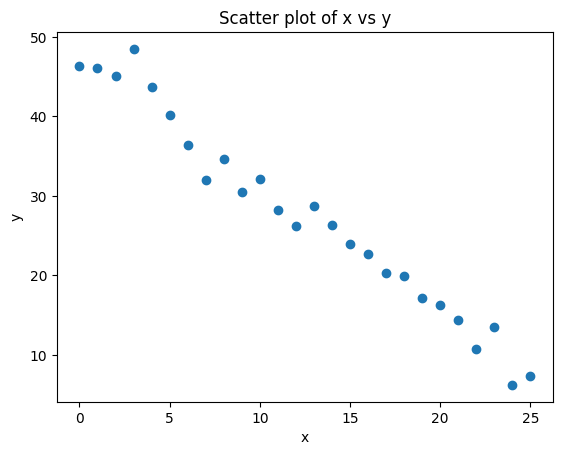

In [18]:
plt.scatter(df['x'], df['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x vs y')
plt.show()

5. Justifier le choix du modèle de régression linéaire simple pour la prédiction

Votre réponse:

A partir des description des données, spécialement l'allure du graphe, on a constaté un comportement linéaire de $y$ par rapport à $x$, avec $y(x) = -\alpha x + c$, $\alpha$ une constante réelle positive et $c$ une constante réelle.

### Construction du modèle de régression linéaire simple

6. Identifier la variable indépendante et celle dépendante dans le dataset. Faire ensuite une extraction pour avoir les deux variables sous format dataframe.

In [ ]:
# Independant variable
x = df['x'].copy()

# Dependant variable
y = df['y'].copy()

Pour construire le modèle RL (régression linéaire) simple y = w0 + w1*x, il nous faut déterminer les coefficients :
* w0: ordonnée à l'origine (ou intercept en anglais)
* w1: coefficient directeur/pente (ou slope en anglais)

Nous procédons à la méthode des moindres carrés ordinaire (ou ordinary least squares (OLS) en anglais)

Référence: https://perso.lpsm.paris/~aguyader/files/teaching/Regression.pdf (chapitre 1)

7. Compléter le code suivant (OLS function)

In [28]:
def compute_coefficient(x, y):
    n = len(x)
    x_mean = x.mean()
    y_mean = y.mean()

    numerator = 0
    denominator = 0

    for i in range(n):
        numerator += (x[i] - x_mean) * (y[i] - y_mean)
        denominator += (x[i] - x_mean) ** 2

    # Calculate coefficients
    slope = numerator / denominator
    intercept = y_mean - slope * x_mean

    return slope, intercept

8) Phase d'entrainement (training)

Il s'agit de déterminer les coefficients w0 et w1 à partir du dataset

In [29]:
w1, w0 = compute_coefficient(x, y)
print(f'Coefficient w1 (slope): {w1}')
print(f'Coefficient w0 (intercept): {w0}')

Coefficient w1 (slope): -1.6188168394132634
Coefficient w0 (intercept): 47.839382220563934


Remarque: 

Il existe la fonction "LinearRegression" dans la bibliothèque ScikitLearn https://scikit-learn.org/stable/ qui fait la même chose

https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html

9. Entrainement par le modèle RL dans ScikitLearn

Commenter le code suivant en expliquant ce que chaque ligne de code fait.

Faire tourner le code.

Le code ne fonctionne pas, expliquer et corriger

In [31]:
# Importing the LinearRegression class from scikit-learn
from sklearn.linear_model import LinearRegression

# Creating an instance of the LinearRegression model
model_RL = LinearRegression() 

# Training the model on the data
# model_RL.fit(x,y)

# The code does not work because the fit method expects a
# 2D array for the independent variable (x) and a 1D array
# for the dependent variable (y). To fix this, we need to reshape
# x to be a 2D array. We can do this by using the reshape method
# from numpy. Here is the corrected code:
x_reshaped = x.values.reshape(-1, 1)
model_RL.fit(x_reshaped, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


10. Afficher les coefficients w0 et w1 et comparer avec ceux obtenus de la question 8.

Indice: intercept_, coef_

In [34]:
print(f'w1 scikit-learn: {model_RL.coef_[0]} | w1 calculé: {w1}')
print(f'w0 scikit-learn: {model_RL.intercept_} | w0 calculé: {w0}')

print(f'Les résultats sont très proches, ce qui confirme que notre implémentation manuelle de la régression linéaire est correcte et que les coefficients calculés sont similaires à ceux obtenus avec scikit-learn.')

w1 scikit-learn: -1.6188168394132625 | w1 calculé: -1.6188168394132634
w0 scikit-learn: 47.83938222056392 | w0 calculé: 47.839382220563934
Les résultats sont très proches, ce qui confirme que notre implémentation manuelle de la régression linéaire est correcte et que les coefficients calculés sont similaires à ceux obtenus avec scikit-learn.


#### Remarque importante: 
Avant de développer vos propres fonctions en Machine Learning, prenez l'habitude de rechercher des solutions existantes. Ces dernières sont souvent le fruit du travail d'experts, optimisées et robustes grâce aux retours d'expérience de la communauté. Cela vous permettra de gagner du temps, d'éviter les erreurs courantes et de bénéficier de code de qualité. La question 7 a pour objectif principal d'illustrer de manière pédagogique le processus d'entraînement d'un modèle.

### Prédiction à l'aide du modèle RL entrainé

11. Utiliser le modèle model_RL pour faire la prédiction: 
* L'entrée (input): x
* La sortie (output): nommée ypred

In [37]:
y_pred = model_RL.predict(x_reshaped)

12. Donner la définition et ensuite déterminer le score, les erreurs MSE, RMSE, MAE, MAPE du modèle model_RL

référence: https://kobia.fr/regression-metrics-quelle-metrique-choisir/

Votre réponse:

Définitions:

Soit $n$ la quantité de valeurs dans le jeux de données, $y$ la valeur réelle de la variable dépendant, $\hat{y}$ la valeur prédite par le modèle et $ \bar{a} = \frac{1}{n}\sum_{i=1}^n{a_i} $. Alors :
* **Score:** $ 1 - \frac{\sum_{i=1}^n{\left( y_i - \hat{y}_i \right)^2}}{\sum_{i=1}^n{\left( y_i - \bar{y}_i \right)^2}} $
* **MSE:** $ \frac{1}{n}\sum_{i=1}^n{\left(y_i-\hat{y}_i\right)^2} $
* **RMSE:** $ \sqrt{\frac{1}{n}\sum_{i=1}^n{\left(y_i-\hat{y}_i\right)^2}} $
* **MAE:** $ \frac{1}{n}\sum_{i=1}^n{\left|y_i-\hat{y}_i\right|} $
* **MAPE:** $ \frac{1}{n}\sum_{i=1}^n{\left|\frac{y_i-\hat{y}_i}{y_i}\right|} $

In [38]:
R2 = model_RL.score(x_reshaped, y)
print("Coefficient de détermination (R²) :", R2)
MSE = np.mean((y - y_pred) ** 2)
print("Mean Squared Error (MSE) :", MSE)
RMSE = np.sqrt(MSE)
print("Root Mean Squared Error (RMSE) :", RMSE)
MAE = np.mean(np.abs(y - y_pred))
print("Mean Absolute Error (MAE) :", MAE)
MAPE = np.mean(np.abs((y - y_pred) / y)) * 100
print("Mean Absolute Percentage Error (MAPE) :", MAPE, "%")

Coefficient de détermination (R²) : 0.973474111246914
Mean Squared Error (MSE) : 4.016645385459095
Root Mean Squared Error (RMSE) : 2.0041570261481745
Mean Absolute Error (MAE) : 1.4723738901899353
Mean Absolute Percentage Error (MAPE) : 6.858461116855029 %


Commenter sur la précision du modèle et le choix initial de ce modèle RL

Votre réponse:

Selon tous les erreurs au-dessus, le modèle est **très précis** et **bien adapté** à ce jeux de données. C'est bien visible avec le *score* R² étant haut et les erreurs sont bas par rapport aux valeurs réeles $y$.

13. Tracer le nuage des points des données et tracer la droite donnée par le modèle

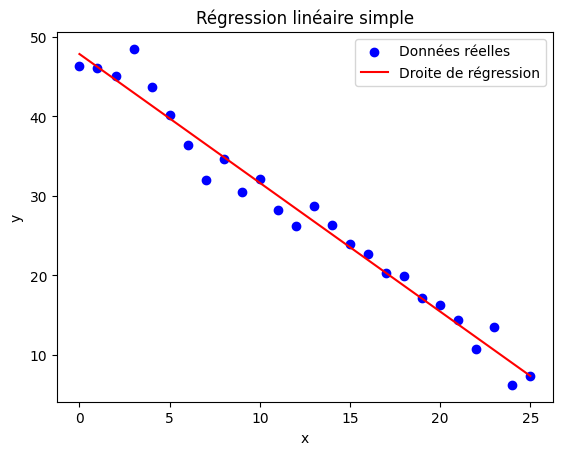

In [39]:
plt.scatter(x, y, color='blue', label='Données réelles')
plt.plot(x, y_pred, color='red', label='Droite de régression')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Régression linéaire simple')
plt.legend()
plt.show()

14. Estimer y pour x=20.5. 

In [40]:
y1 = model_RL.predict([[20.5]])
print(f'La prédiction pour x = 20.5 est y = {y1[0]}')

La prédiction pour x = 20.5 est y = 14.653637012592036


15. Mettre ce point sur le graphique précédent

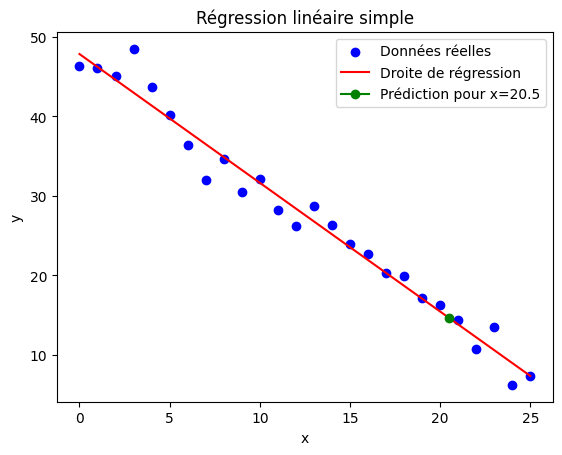

In [43]:
plt.scatter(x, y, color='blue', label='Données réelles')
plt.plot(x, y_pred, color='red', label='Droite de régression')
plt.plot([20.5], y1, color='green', marker='o', label='Prédiction pour x=20.5')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Régression linéaire simple')
plt.legend()
plt.show()

#### Remarque importante: 
Ce nouveau point de données est particulièrement intéressant car il n'est pas représenté dans l'ensemble d'entraînement. Une prédiction sur ce point nous permettra d'évaluer de manière plus fine la capacité du modèle à généraliser à des situations inédites.

16. Peut-on évaluer la précision de prédiction pour ce nouveau point? 

Votre réponse:

On ne peut pas évaluer la précision de prédiction pour ce nouveau point car il n'existe pas le donnée réelle $y$ pour $x=20.5$.

17. Votre solution pour évaluer la capacité du modèle à généraliser à des situations inédites?

Votre réponse:

Utiliser les différents indicateurs d'érreurs qu'on a listé en-dessus.

## Partie 2 - Une autre base de données - séparation train/test  

18. Importer "dataset2.csv" et faire des analyses exploratoires comme dans la partie 1

In [ ]:
# Votre code

19. Peut-on utiliser le modèle RL simple pour prédire "brain weight" à partir de "head size" ? Justifier

Votre réponse:

20. Construire un modèle RL en utilisant SkicitLearn

In [ ]:
# Votre code



21. Entrainer ce modèle sur différentes partitions train/test en utilisant les ratios suivants:
* 20% train/ 80% test
* 50% train/ 50% test
* 80% train/ 20% test

Les partitions seront créées en respectant l'ordre d'apparition des données dans l'ensemble.

Pour chaque partition, afficher les métriques: score, MSE, RMSE, MAE, MAPE pour train et puis pour test

Comparer et Commenter les résultats

In [ ]:
# votre code


Afin d'assurer une représentativité statistique de l'ensemble d'entraînement, il est courant de procéder à une partition aléatoire des données en ensembles d'entraînement et de test.

La séparation aléatoire de données peut se faire à l'aide de la fonction train_test_split https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html#sklearn.model_selection.train_test_split

22. Question optionnelle: Refaire la question 21 avec cette nouvelle approche et de commenter les résultats obtenus.

